# Part 1: Synthetic Dataset (Understanding Margin)

In [5]:
# ==========================================================
# COMPLETE SVM DEMONSTRATION ON SYNTHETIC DATA
# Linear SVM + RBF SVM with Proper Visualizations
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Generate Data

In [6]:
# ----------------------------------------------------------
# 1️⃣ Generate Synthetic Binary Dataset
# ----------------------------------------------------------

X, y = make_blobs(n_samples=100, centers=2, random_state=42)

# Convert labels to -1 and +1
y = np.where(y == 0, -1, 1)



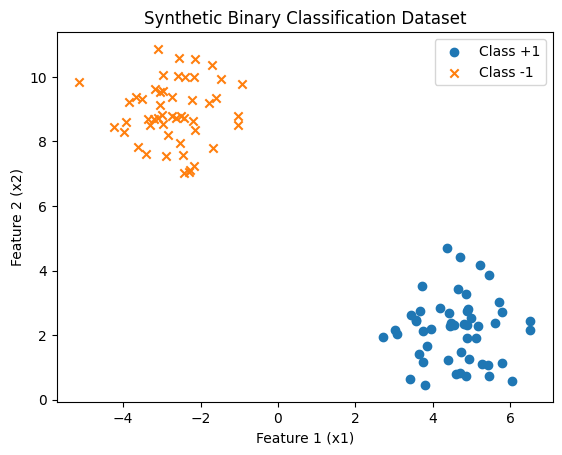

In [7]:
# ----------------------------------------------------------
# 2️⃣ Scatter Plot of Raw Data
# ----------------------------------------------------------

plt.figure()
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='o', label='Class +1')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], marker='x', label='Class -1')
plt.xlabel("Feature 1 (x1)")
plt.ylabel("Feature 2 (x2)")
plt.title("Synthetic Binary Classification Dataset")
plt.legend()
plt.show()

# Train Linear SVM

In [8]:
# ----------------------------------------------------------
# 3️⃣ Linear SVM
# ----------------------------------------------------------

linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X, y)

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = linear_svm.decision_function(grid)
Z = Z.reshape(xx.shape)

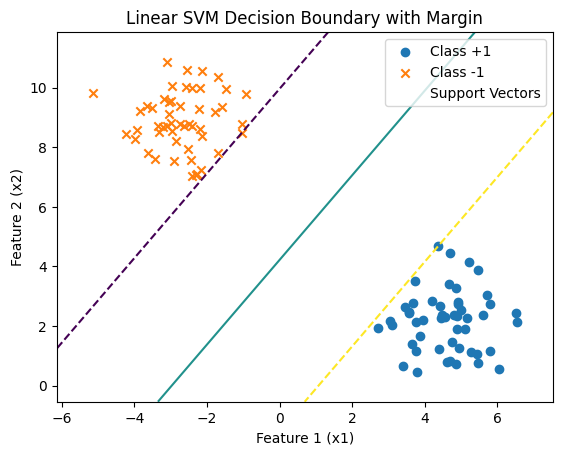

In [9]:
# Plot Linear Decision Boundary + Margin
plt.figure()
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='o', label='Class +1')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], marker='x', label='Class -1')

plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'])
plt.scatter(linear_svm.support_vectors_[:, 0],
            linear_svm.support_vectors_[:, 1],
            s=120, facecolors='none', label='Support Vectors')

plt.xlabel("Feature 1 (x1)")
plt.ylabel("Feature 2 (x2)")
plt.title("Linear SVM Decision Boundary with Margin")
plt.legend()
plt.show()

In [10]:
print("Number of Support Vectors (Linear SVM):",
      len(linear_svm.support_vectors_))

Number of Support Vectors (Linear SVM): 2


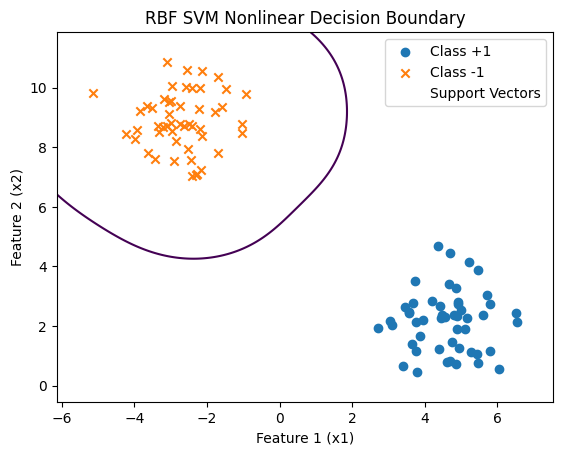

Number of Support Vectors (RBF SVM): 22


In [11]:
# ----------------------------------------------------------
# 4️⃣ RBF SVM (Nonlinear)
# ----------------------------------------------------------

rbf_svm = SVC(kernel='rbf', C=1, gamma=0.5)
rbf_svm.fit(X, y)

Z_rbf = rbf_svm.decision_function(grid)
Z_rbf = Z_rbf.reshape(xx.shape)

# Plot RBF Decision Boundary
plt.figure()
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], marker='o', label='Class +1')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], marker='x', label='Class -1')

plt.contour(xx, yy, Z_rbf, levels=[0])
plt.scatter(rbf_svm.support_vectors_[:, 0],
            rbf_svm.support_vectors_[:, 1],
            s=120, facecolors='none', label='Support Vectors')

plt.xlabel("Feature 1 (x1)")
plt.ylabel("Feature 2 (x2)")
plt.title("RBF SVM Nonlinear Decision Boundary")
plt.legend()
plt.show()

print("Number of Support Vectors (RBF SVM):",
      len(rbf_svm.support_vectors_))